In [51]:
# This Python 3 environment comes with many helpful analytics libraries installed
# It is defined by the kaggle/python Docker image: https://github.com/kaggle/docker-python
# For example, here's several helpful packages to load

import numpy as np # linear algebra
import pandas as pd # data processing, CSV file I/O (e.g. pd.read_csv)

# Input data files are available in the read-only "../input/" directory
# For example, running this (by clicking run or pressing Shift+Enter) will list all files under the input directory

import os
for dirname, _, filenames in os.walk('/kaggle/input'):
    for filename in filenames:
        print(os.path.join(dirname, filename))

# You can write up to 20GB to the current directory (/kaggle/working/) that gets preserved as output when you create a version using "Save & Run All" 
# You can also write temporary files to /kaggle/temp/, but they won't be saved outside of the current session

/kaggle/input/datasets/mayankgupta17/hcltech1/online_retail_II.xlsx


In [52]:
# Data manipulation
import pandas as pd
import numpy as np

# Date handling
from datetime import datetime, timedelta

# Visualization
import matplotlib.pyplot as plt
import seaborn as sns

# Machine Learning
from sklearn.model_selection import train_test_split
from sklearn.preprocessing import OneHotEncoder
from sklearn.linear_model import LinearRegression
from sklearn.ensemble import RandomForestRegressor

# Metrics
from sklearn.metrics import mean_absolute_error, mean_squared_error, r2_score

# Model saving
import joblib

In [53]:
df_raw = pd.read_excel('/kaggle/input/datasets/mayankgupta17/hcltech1/online_retail_II.xlsx')

df_raw.columns = df_raw.columns.str.strip().str.replace(' ', '')

print("Dataset Shape:", df_raw.shape)

df_raw.head()

Dataset Shape: (525461, 8)


,Invoice,StockCode,Description,Quantity,InvoiceDate,Price,CustomerID,Country
0,489434,85048,15CM CHRISTMAS GLASS BALL 20 LIGHTS,12,2009-12-01 07:45:00,6.95,13085.0,United Kingdom
1,489434,79323P,PINK CHERRY LIGHTS,12,2009-12-01 07:45:00,6.75,13085.0,United Kingdom
2,489434,79323W,WHITE CHERRY LIGHTS,12,2009-12-01 07:45:00,6.75,13085.0,United Kingdom
3,489434,22041,"RECORD FRAME 7"" SINGLE SIZE",48,2009-12-01 07:45:00,2.10,13085.0,United Kingdom
4,489434,21232,STRAWBERRY CERAMIC TRINKET BOX,24,2009-12-01 07:45:00,1.25,13085.0,United Kingdom


In [54]:
df = df_raw.copy()

In [55]:
df = df.dropna(subset=['CustomerID'])
df['CustomerID'] = df['CustomerID'].astype(int)

In [56]:
df = df.drop_duplicates()

In [57]:
df['InvoiceDate'] = pd.to_datetime(df['InvoiceDate'])

In [58]:
df['TotalSpend'] = df['Quantity'] * df['Price']

In [59]:
df = df[df['Price'] > 0]

In [60]:
df = df[df['Quantity'] > 0]

In [61]:
df = df.sort_values('InvoiceDate')

In [62]:
print("Clean dataset shape:", df.shape)

df.head()

Clean dataset shape: (400916, 9)


,Invoice,StockCode,Description,Quantity,InvoiceDate,Price,CustomerID,Country,TotalSpend
0,489434,85048,15CM CHRISTMAS GLASS BALL 20 LIGHTS,12,2009-12-01 07:45:00,6.95,13085,United Kingdom,83.4
1,489434,79323P,PINK CHERRY LIGHTS,12,2009-12-01 07:45:00,6.75,13085,United Kingdom,81.0
2,489434,79323W,WHITE CHERRY LIGHTS,12,2009-12-01 07:45:00,6.75,13085,United Kingdom,81.0
3,489434,22041,"RECORD FRAME 7"" SINGLE SIZE",48,2009-12-01 07:45:00,2.10,13085,United Kingdom,100.8
4,489434,21232,STRAWBERRY CERAMIC TRINKET BOX,24,2009-12-01 07:45:00,1.25,13085,United Kingdom,30.0


In [63]:
cutoff_date = df['InvoiceDate'].max() - pd.Timedelta(days=30)

print("Cutoff Date:", cutoff_date)

Cutoff Date: 2010-11-09 20:01:00


In [64]:
df_past = df[df['InvoiceDate'] <= cutoff_date]

df_future = df[df['InvoiceDate'] > cutoff_date]

print("Past transactions:", df_past.shape)
print("Future transactions:", df_future.shape)

Past transactions: (344023, 9)
Future transactions: (56893, 9)


In [65]:
future_spend = df_future.groupby('CustomerID')['TotalSpend'].sum().reset_index()

future_spend = future_spend.rename(columns={'TotalSpend':'FutureSpend30d'})

future_spend.head()

,CustomerID,FutureSpend30d
0,12347,711.79
1,12351,300.93
2,12352,343.80
3,12356,2649.86
4,12357,12079.99


In [66]:
snapshot_date = df_past['InvoiceDate'].max()

In [67]:
rfm = df_past.groupby('CustomerID').agg({

    'InvoiceDate': lambda x: (snapshot_date - x.max()).days,

    'Invoice': 'nunique',

    'TotalSpend': 'sum'

}).reset_index()

rfm.columns = ['CustomerID','Recency','Frequency','Monetary']

rfm.head()

,CustomerID,Recency,Frequency,Monetary
0,12346,134,11,372.86
1,12347,9,1,611.53
2,12348,43,1,222.16
3,12349,12,3,2671.14
4,12353,13,1,317.76


In [68]:
rfm['AvgOrderValue'] = rfm['Monetary'] / rfm['Frequency']

In [69]:
quantity = df_past.groupby('CustomerID')['Quantity'].sum().reset_index()

quantity.columns = ['CustomerID','TotalQuantity']

rfm = rfm.merge(quantity, on='CustomerID')

In [70]:
lifetime = df_past.groupby('CustomerID')['InvoiceDate'].agg(['min','max']).reset_index()

lifetime['CustomerLifetime'] = (lifetime['max'] - lifetime['min']).dt.days

lifetime = lifetime[['CustomerID','CustomerLifetime']]

rfm = rfm.merge(lifetime, on='CustomerID')

In [71]:
country = df_past.groupby('CustomerID')['Country'].first().reset_index()

rfm = rfm.merge(country, on='CustomerID')

In [72]:
data = rfm.merge(future_spend, on='CustomerID', how='left')

print("Customer dataset shape:", data.shape)

data.head()

Customer dataset shape: (4037, 9)


,CustomerID,Recency,Frequency,Monetary,AvgOrderValue,TotalQuantity,CustomerLifetime,Country,FutureSpend30d
0,12346,134,11,372.86,33.896364,70,196,United Kingdom,NaN
1,12347,9,1,611.53,611.530000,509,0,Iceland,711.79
2,12348,43,1,222.16,222.160000,373,0,Finland,NaN
3,12349,12,3,2671.14,890.380000,993,181,Italy,NaN
4,12353,13,1,317.76,317.760000,192,0,Bahrain,NaN


In [73]:
data['FutureSpend30d'] = data['FutureSpend30d'].fillna(0)

In [74]:
X = data.drop(columns=['CustomerID','FutureSpend30d'])

y = data['FutureSpend30d']

In [75]:
X = pd.get_dummies(X, columns=['Country'], drop_first=True)

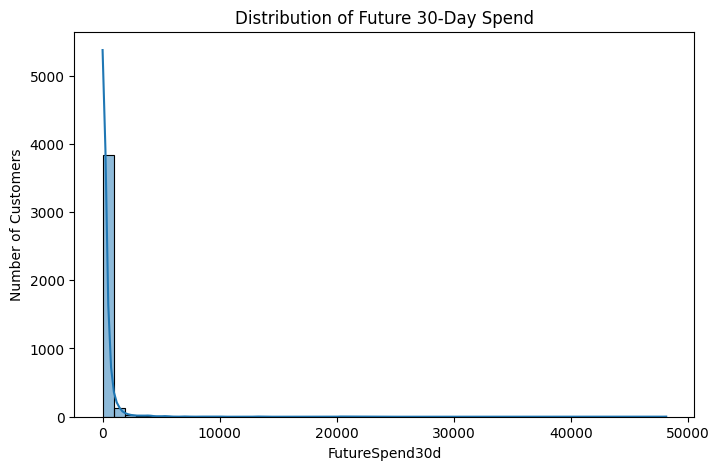

In [76]:
import matplotlib.pyplot as plt
import seaborn as sns

plt.figure(figsize=(8,5))
sns.histplot(data['FutureSpend30d'], bins=50, kde=True)

plt.title("Distribution of Future 30-Day Spend")
plt.xlabel("FutureSpend30d")
plt.ylabel("Number of Customers")

plt.show()

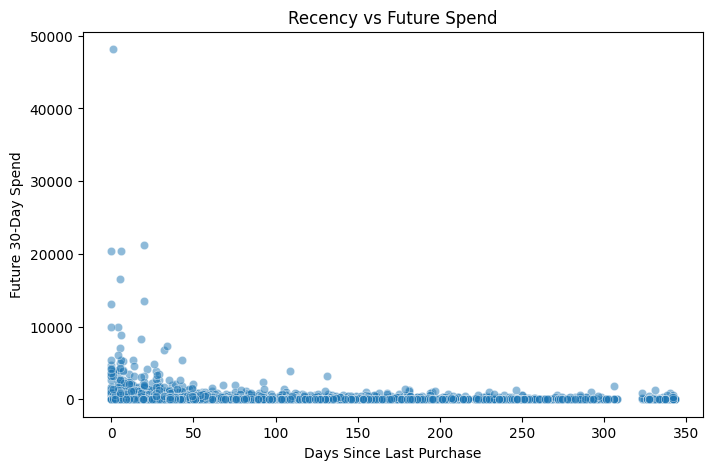

In [77]:
plt.figure(figsize=(8,5))

sns.scatterplot(x=data['Recency'], y=data['FutureSpend30d'], alpha=0.5)

plt.title("Recency vs Future Spend")
plt.xlabel("Days Since Last Purchase")
plt.ylabel("Future 30-Day Spend")

plt.show()

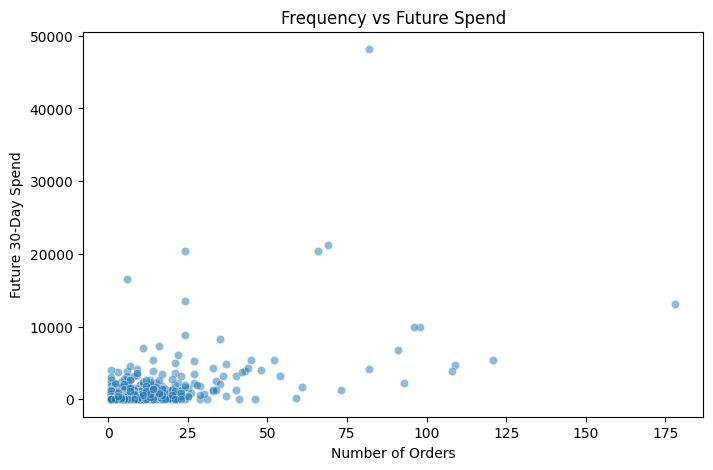

In [78]:
plt.figure(figsize=(8,5))

sns.scatterplot(x=data['Frequency'], y=data['FutureSpend30d'], alpha=0.5)

plt.title("Frequency vs Future Spend")
plt.xlabel("Number of Orders")
plt.ylabel("Future 30-Day Spend")

plt.show()

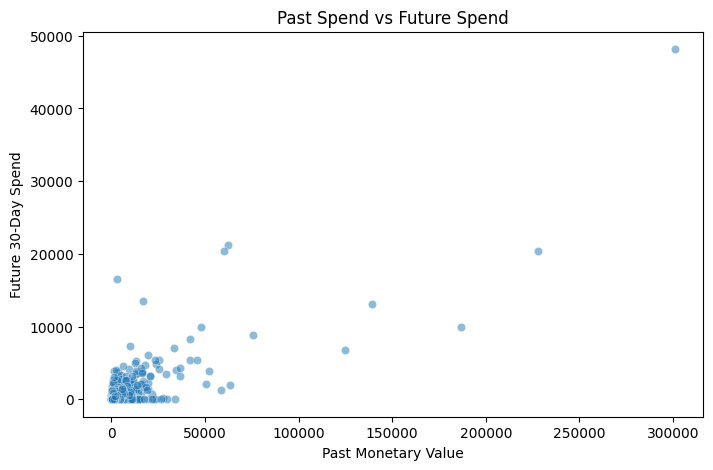

In [79]:
plt.figure(figsize=(8,5))

sns.scatterplot(x=data['Monetary'], y=data['FutureSpend30d'], alpha=0.5)

plt.title("Past Spend vs Future Spend")
plt.xlabel("Past Monetary Value")
plt.ylabel("Future 30-Day Spend")

plt.show()

In [80]:
# Features
X = data.drop(columns=['CustomerID','FutureSpend30d'])

# Target (log transform to reduce skew)
y = np.log1p(data['FutureSpend30d'])

print("Feature shape:", X.shape)
print("Target shape:", y.shape)

Feature shape: (4037, 7)
Target shape: (4037,)


In [81]:
X = pd.get_dummies(X, columns=['Country'], drop_first=True)

print("New feature shape:", X.shape)

New feature shape: (4037, 42)


In [82]:
from sklearn.model_selection import train_test_split

X_train, X_test, y_train, y_test = train_test_split(
    X,
    y,
    test_size=0.2,
    random_state=42
)

print("Train size:", X_train.shape)
print("Test size:", X_test.shape)

Train size: (3229, 42)
Test size: (808, 42)


In [83]:
from sklearn.linear_model import LinearRegression

lr = LinearRegression()

lr.fit(X_train, y_train)

LinearRegression()

In [84]:
y_pred_lr = lr.predict(X_test)

In [85]:
from sklearn.metrics import mean_absolute_error, mean_squared_error, r2_score
import numpy as np

mae_lr = mean_absolute_error(y_test, y_pred_lr)
rmse_lr = np.sqrt(mean_squared_error(y_test, y_pred_lr))
r2_lr = r2_score(y_test, y_pred_lr)

print("Linear Regression Performance")
print("MAE:", mae_lr)
print("RMSE:", rmse_lr)
print("R2:", r2_lr)

Linear Regression Performance
MAE: 2.2906897486792537
RMSE: 2.669697477178322
R2: 0.1712623573564327


In [86]:
from sklearn.ensemble import RandomForestRegressor

rf = RandomForestRegressor(
    n_estimators=200,
    max_depth=10,
    random_state=42,
    n_jobs=-1
)

rf.fit(X_train, y_train)

RandomForestRegressor(max_depth=10, n_estimators=200, n_jobs=-1,
                      random_state=42)

In [87]:
y_pred_rf = rf.predict(X_test)

In [88]:
mae_rf = mean_absolute_error(y_test, y_pred_rf)
rmse_rf = np.sqrt(mean_squared_error(y_test, y_pred_rf))
r2_rf = r2_score(y_test, y_pred_rf)

print("Random Forest Performance")
print("MAE:", mae_rf)
print("RMSE:", rmse_rf)
print("R2:", r2_rf)

Random Forest Performance
MAE: 2.064657757845917
RMSE: 2.5427115580127904
R2: 0.2482262489658129


In [89]:
results = pd.DataFrame({
    "Model": ["Linear Regression","Random Forest"],
    "MAE": [mae_lr, mae_rf],
    "RMSE": [rmse_lr, rmse_rf],
    "R2": [r2_lr, r2_rf]
})

results

,Model,MAE,RMSE,R2
0,Linear Regression,2.290690,2.669697,0.171262
1,Random Forest,2.064658,2.542712,0.248226


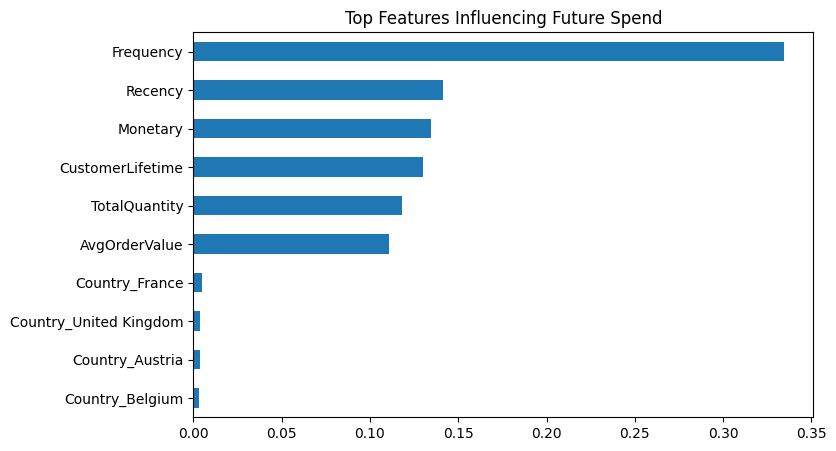

In [90]:
import matplotlib.pyplot as plt

importances = rf.feature_importances_

feat_imp = pd.Series(importances, index=X.columns)

top_features = feat_imp.sort_values(ascending=False).head(10)

plt.figure(figsize=(8,5))

top_features.sort_values().plot(kind='barh')

plt.title("Top Features Influencing Future Spend")

plt.show()

In [91]:
# Predict in log scale
y_pred_log = rf.predict(X_test)

# Convert predictions back to original scale
y_pred = np.expm1(y_pred_log)

# Convert actual values back
y_test_actual = np.expm1(y_test)

# Evaluate
from sklearn.metrics import mean_absolute_error, mean_squared_error, r2_score
import numpy as np

mae = mean_absolute_error(y_test_actual, y_pred)
rmse = np.sqrt(mean_squared_error(y_test_actual, y_pred))
r2 = r2_score(y_test_actual, y_pred)

print("MAE:", mae)
print("RMSE:", rmse)
print("R2:", r2)

MAE: 241.43151208330787
RMSE: 971.6229508186848
R2: 0.30894234707821167


In [92]:
# Example customer data
sample_customer = {
    'Recency': 10,
    'Frequency': 5,
    'Monetary': 1200,
    'AvgOrderValue': 240,
    'TotalQuantity': 300,
    'CustomerLifetime': 200,
    'Country_United Kingdom': 1
}

# Convert to dataframe
sample_df = pd.DataFrame([sample_customer])

# Align columns with training data
sample_df = sample_df.reindex(columns=X.columns, fill_value=0)

# Predict (log scale)
pred_log = rf.predict(sample_df)

# Convert back to actual spend
pred_spend = np.expm1(pred_log)

print("Predicted 30-day customer spend:", pred_spend[0])

Predicted 30-day customer spend: 33.2525014475377


In [94]:
import pickle

# Save trained model
with open('/kaggle/working/customer_spend_model.pkl', 'wb') as f:
    pickle.dump(rf, f)

# Save feature columns
with open('/kaggle/working/model_features.pkl', 'wb') as f:
    pickle.dump(X.columns.tolist(), f)

print("Model saved successfully!")

Model saved successfully!
